# This is a basic notebook that demonstrates the ability to draw, save, and load a packing #

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pyCudaPolygon as pcp

### First we define the attributes ###

In [2]:
N = 16
n = 32
kappa = 3.8
phi = 0.7
seed = 444_4444

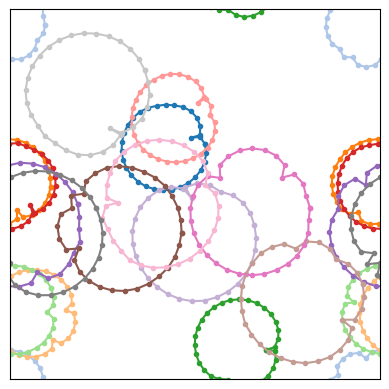

In [3]:
model = pcp.model(size = N * n, seed = seed)
# We can set and minimize the random polygons
model.setRandomPolygons(N, n, kappa = 3.8)
model.setBiPerimeters(ratio = np.sqrt(2), kappa = 3.8)
model.setPhi(1)
_ = model.draw()

In [4]:
np.max(np.abs(model.getEdgeLengths() - model.getTargetEdgeLengths()))

2.0315329279929628e-11

In [5]:
np.max(np.abs(model.getTargetAreas() - model.getAreas()))

2.220446049250313e-16

# Now we save and load

In [6]:
fileName = "testPackings/testPacking.npz"
model.saveModel(fileName, overwrite = True)

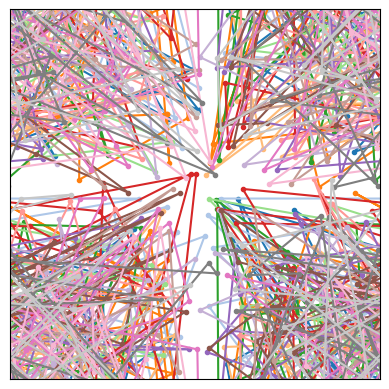

In [7]:
# Let's jumble it up:
model.setVertices(np.random.rand(2 * N * n).reshape(N * n, 2))
model.setTargetEdgeLengths(model.getTargetEdgeLengths() * 100)
model.setTargetAreas(model.getTargetAreas() * 100)
_= model.draw()

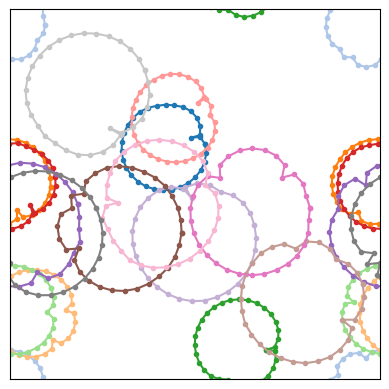

In [8]:
model.loadModel(fileName)
_ = model.draw()

In [9]:
np.max(np.abs(model.getEdgeLengths() - model.getTargetEdgeLengths()))

2.0315329279929628e-11

In [10]:
np.max(np.abs(model.getTargetAreas() - model.getAreas()))

2.220446049250313e-16